In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter
import os

In [2]:
os.chdir('/Users/tergemina/Library/CloudStorage/Dropbox/Ionome_GWAS/1001/github/Supplementary/FigS7/FigS7a/')

In [6]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

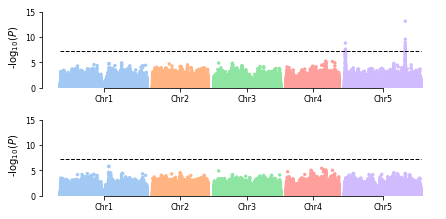

In [7]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)



def plotting(dataframe,idx):
    sns.scatterplot(x='position',
                    y='P',
                    data=dataframe,
                    hue='chr',
                    palette='pastel',
                    marker='o',
                    s=12,
                    linewidth=0,
                    legend=False,
                    ax=ax[idx])
    ax[idx].set_xticks([chr1,chr2,chr3,chr4,chr5]),
    ax[idx].tick_params(axis='both', which='major', labelsize=8)
    ax[idx].set_xticklabels(["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    ax[idx].hlines(y=-np.log10(0.05/len(dataframe)),
                 xmin=min(dataframe['position']),
                 xmax=max(dataframe['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
    ax[idx].set_ylim(0,16)
    
    
classic=parse('690_Mg_blues.assoc.txt.gz')
Chr5_21392702_21392702_282011=parse('690_Mg_blues_Chr5_21405867_21392702_282011.assoc.txt.gz')

cm = 1/2.54
fig , ax = plt.subplots(2,1,figsize=(16*cm,8*cm))
plotting(classic,0)
# ax[0].set_title('all SNPs')
plotting(Chr5_21392702_21392702_282011,1)
# ax[1].set_title('with $\itRAPTOR1A$ and $\itMGR5$ regions as covariates')

plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.tight_layout()
# plt.savefig("FigS6a.pdf", format="pdf",bbox_inches="tight")
plt.savefig("FigS7a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)